⏳ Ładowanie danych...
✅ Dane wczytane pomyślnie!

--- PIERWSZE 5 WIERSZY ---


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN



--- LISTA WSZYSTKICH KOLUMN ---
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification

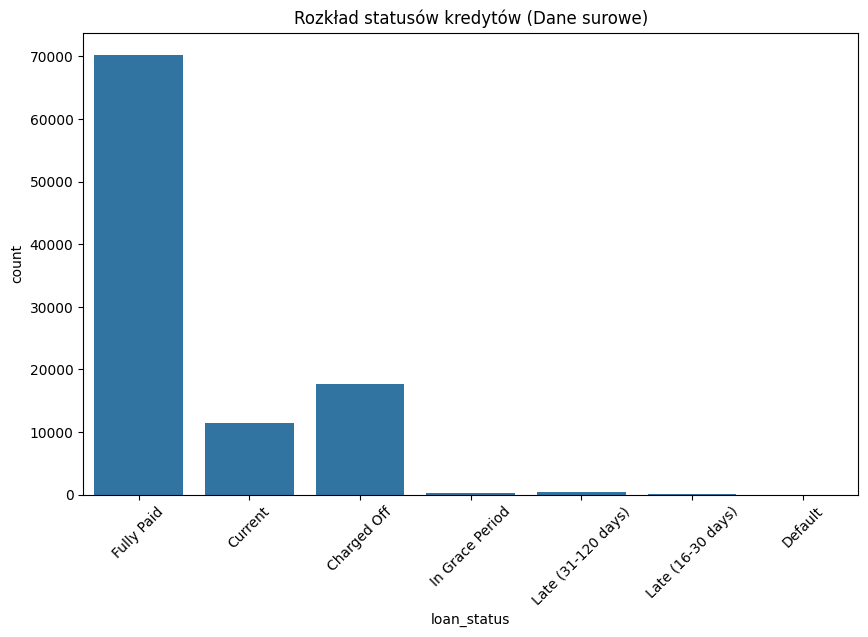


--- TOP 10 KOLUMN Z BRAKAMI DANYCH ---
member_id                              100000
sec_app_num_rev_accts                  100000
sec_app_chargeoff_within_12_mths       100000
sec_app_collections_12_mths_ex_med     100000
sec_app_mths_since_last_major_derog    100000
sec_app_mort_acc                       100000
sec_app_open_acc                       100000
sec_app_revol_util                     100000
revol_bal_joint                        100000
sec_app_open_act_il                    100000
dtype: int64

--- PRZYGOTOWANIE DO ANALIZY KORELACJI ---


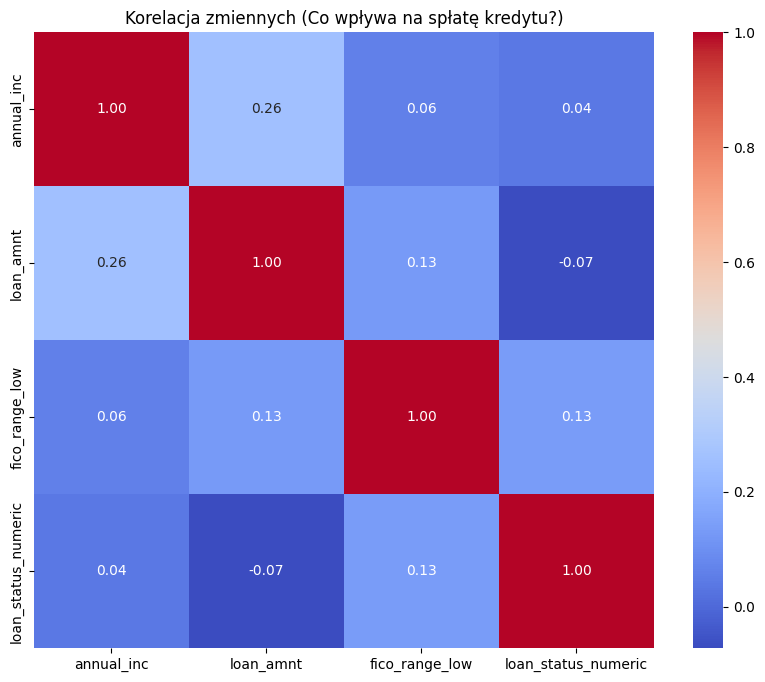

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ładowanie danych wejściowych
print("⏳ Ładowanie danych...")
# Wczytujemy pierwsze 100k wierszy dla wydajności
df = pd.read_csv("data/accepted_2007_to_2018Q4.csv", nrows=100000, low_memory=False)
print("✅ Dane wczytane pomyślnie!")

# 2. CO JEST WEWNĄTRZ? (Podgląd danych)
print("\n--- PIERWSZE 5 WIERSZY ---")
display(df.head())

# 3. JAKIE SĄ KOLUMNY?
print("\n--- LISTA WSZYSTKICH KOLUMN ---")
print(list(df.columns))

# 4. SPRAWDZENIE ZMIENNEJ DOCELOWEJ
print("\n--- STATYSTYKI STATUSÓW KREDYTÓW ---")
print(df['loan_status'].value_counts())

# Wykres 1: Rozkład statusów (Dane surowe)
plt.figure(figsize=(10,6))
sns.countplot(x='loan_status', data=df)
plt.title("Rozkład statusów kredytów (Dane surowe)")
plt.xticks(rotation=45)
plt.show()

# 5. SPRAWDZENIE BRAKUJĄCYCH WARTOŚCI
missing = df.isnull().sum()
print("\n--- TOP 10 KOLUMN Z BRAKAMI DANYCH ---")
print(missing[missing > 0].sort_values(ascending=False).head(10))

# --- TUTAJ ZACZYNA SIĘ NAPRAWA BŁĘDU KeyError ---

print("\n--- PRZYGOTOWANIE DO ANALIZY KORELACJI ---")
# Aby zbudować mapę korelacji, musimy:
# A) Przefiltrować tylko zakończone kredyty (aby analiza była rzetelna)
df_clean = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

# B) Utworzyć kolumnę numeryczną (1 - spłacony, 0 - niespłacony/debolt)
# Tej kolumny brakowało w poprzedniej wersji analizy
df_clean['loan_status_numeric'] = df_clean['loan_status'].apply(lambda x: 1 if x == 'Fully Paid' else 0)

# Wykres 2: Mapa ciepła korelacji (Działa na df_clean)
plt.figure(figsize=(10,8))
sns.heatmap(df_clean[['annual_inc', 'loan_amnt', 'fico_range_low', 'loan_status_numeric']].corr(), 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f")
plt.title("Korelacja zmiennych (Co wpływa na spłatę kredytu?)")
plt.show()